# Facteurs associés à l'accouchement par césarienne au Cameroun
## Analyse basée sur l'Enquête Démographique et de Santé (EDS) — Cameroun 2018

**Variable dépendante :** Accouchement par césarienne (oui/non)  
**Méthode :** Régression logistique univariée et multivariée  
**Source des données :** EDS Cameroun 2018 — Fichiers BR et IR  
**Logiciel :** Python 3

---
### Plan d'analyse
1. Importation des bibliothèques
2. Chargement et exploration initiale
3. Prétraitement (preprocessing)
4. Analyse descriptive univariée
5. Analyse bivariée
6. Régression logistique univariée
7. Régression logistique multivariée
8. Validation du modèle

---
## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Bibliotheques chargees avec succes.')

Bibliotheques chargees avec succes.


---
## 2. Chargement et exploration initiale

In [2]:
# Chargement
df_raw = pd.read_csv('data_cesarienne_complet1.csv')

print(f'Dimensions : {df_raw.shape[0]} observations x {df_raw.shape[1]} variables')
print('\nColonnes disponibles :')
for col in df_raw.columns:
    print(f'  - {col}')

Dimensions : 9717 observations x 17 variables

Colonnes disponibles :
  - v001
  - v002
  - v003
  - delivery_by_caesarean_section_m17
  - number_of_antenatal_visits_during_p_m14
  - place_of_delivery_m15
  - sex_of_child_b4
  - current_age_of_child_b8
  - v005
  - Respondent_s_current_age_v012
  - Type_of_place_of_residence_v025
  - Region_v024
  - Highest_educational_level_v106
  - Wealth_index_combined_v190
  - Total_children_ever_born_v201
  - Current_marital_status_v501
  - Wanted_last_child_v367


In [3]:
df_raw.head()

,v001,v002,v003,delivery_by_caesarean_section_m17,number_of_antenatal_visits_during_p_m14,place_of_delivery_m15,sex_of_child_b4,current_age_of_child_b8,v005,Respondent_s_current_age_v012,Type_of_place_of_residence_v025,Region_v024,Highest_educational_level_v106,Wealth_index_combined_v190,Total_children_ever_born_v201,Current_marital_status_v501,Wanted_last_child_v367
0,1,125,2,no,5,integrated health center/dispensary,male,1.000,990064,31,Urban,Far-North,Secondary,Poorer,4,Married,Wanted then
1,1,125,3,no,4,respondent's home,female,2.000,990064,19,Urban,Far-North,No education,Poorer,1,No longer living together/separated,Wanted then
2,1,147,2,no,6,integrated health center/dispensary,female,2.000,990064,22,Urban,Far-North,Secondary,Richer,1,Married,Wanted then
3,1,191,3,no,2,integrated health center/dispensary,female,1.000,990064,20,Urban,Far-North,Primary,Middle,1,Married,Wanted then
4,1,198,1,no,1,respondent's home,female,4.000,990064,26,Urban,Far-North,Primary,Middle,4,Married,Wanted then


In [4]:
resume = pd.DataFrame({
    'Type': df_raw.dtypes,
    'Manquants (n)': df_raw.isna().sum(),
    'Manquants (%)': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'Exemple': df_raw.iloc[0]
})
print('Resume du dataset brut :')
print(resume.to_string())

Resume du dataset brut :
                                            Type  Manquants (n)  Manquants (%)                              Exemple
v001                                       int64              0          0.000                                    1
v002                                       int64              0          0.000                                  125
v003                                       int64              0          0.000                                    2
delivery_by_caesarean_section_m17         object              0          0.000                                   no
number_of_antenatal_visits_during_p_m14   object           3266         33.600                                    5
place_of_delivery_m15                     object              0          0.000  integrated health center/dispensary
sex_of_child_b4                           object              0          0.000                                 male
current_age_of_child_b8                  float6

In [5]:
df_raw.describe().round(2)

,v001,v002,v003,current_age_of_child_b8,v005,Respondent_s_current_age_v012,Total_children_ever_born_v201
count,9717.000,9717.000,9717.000,9070.000,9717.000,9717.000,9717.000
mean,235.710,617.270,3.300,1.960,1033422.140,28.220,3.850
std,134.090,353.170,3.060,1.420,644366.140,6.680,2.390
min,1.000,1.000,1.000,0.000,25295.000,15.000,1.000
25%,118.000,310.000,2.000,1.000,585051.000,23.000,2.000
50%,240.000,622.000,2.000,2.000,876795.000,28.000,3.000
75%,351.000,925.000,3.000,3.000,1330409.000,33.000,5.000
max,469.000,1221.000,34.000,4.000,5250016.000,49.000,16.000


---
## 3. Pretraitement

### 3.1 Valeurs manquantes

Variables avec valeurs manquantes :
                               Variable  Manquants (n)  Manquants (%)
number_of_antenatal_visits_during_p_m14           3266         33.600
                current_age_of_child_b8            647          6.700


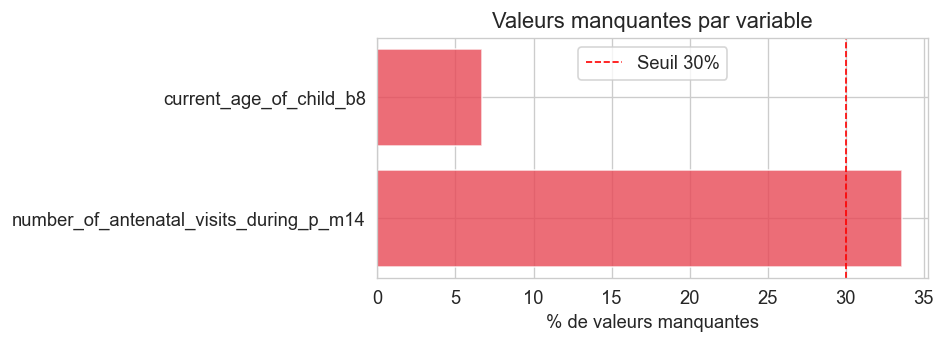

In [6]:
missing = pd.DataFrame({
    'Variable': df_raw.columns,
    'Manquants (n)': df_raw.isna().sum().values,
    'Manquants (%)': (df_raw.isna().sum() / len(df_raw) * 100).round(1).values
})
missing = missing[missing['Manquants (n)'] > 0].sort_values('Manquants (%)', ascending=False)

if len(missing) > 0:
    print('Variables avec valeurs manquantes :')
    print(missing.to_string(index=False))
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.barh(missing['Variable'], missing['Manquants (%)'], color='#E84855', alpha=0.8)
    ax.axvline(x=30, color='red', linestyle='--', linewidth=1, label='Seuil 30%')
    ax.set_xlabel('% de valeurs manquantes')
    ax.set_title('Valeurs manquantes par variable')
    ax.legend()
    plt.tight_layout()
    plt.savefig('fig_valeurs_manquantes.png', bbox_inches='tight')
    plt.show()
else:
    print('Aucune valeur manquante.')

In [9]:
df_raw.isna().sum()

v001                                          0
v002                                          0
v003                                          0
delivery_by_caesarean_section_m17             0
number_of_antenatal_visits_during_p_m14    3266
place_of_delivery_m15                         0
sex_of_child_b4                               0
current_age_of_child_b8                     647
v005                                          0
Respondent_s_current_age_v012                 0
Type_of_place_of_residence_v025               0
Region_v024                                   0
Highest_educational_level_v106                0
Wealth_index_combined_v190                    0
Total_children_ever_born_v201                 0
Current_marital_status_v501                   0
Wanted_last_child_v367                        0
dtype: int64

In [10]:
#5-remplacer les donnees maquantes
df_raw.number_of_antenatal_visits_during_p_m14.fillna(df_raw.number_of_antenatal_visits_during_p_m14.mode(),inplace=True) ##inplace=true remplacer et appliquer dans le jeu de donnees

In [11]:
df_raw.current_age_of_child_b8.fillna(df_raw.current_age_of_child_b8.mean(),inplace=True)

In [12]:
df_raw.isna().sum()

v001                                          0
v002                                          0
v003                                          0
delivery_by_caesarean_section_m17             0
number_of_antenatal_visits_during_p_m14    3266
place_of_delivery_m15                         0
sex_of_child_b4                               0
current_age_of_child_b8                       0
v005                                          0
Respondent_s_current_age_v012                 0
Type_of_place_of_residence_v025               0
Region_v024                                   0
Highest_educational_level_v106                0
Wealth_index_combined_v190                    0
Total_children_ever_born_v201                 0
Current_marital_status_v501                   0
Wanted_last_child_v367                        0
dtype: int64

### 3.2 Recodage des variables

In [ ]:
df = df_raw.copy()

# ── Variable dependante ─────────────────────────────────────────────────
# delivery_by_caesarean_section_m17 : 'yes'=1, 'no'=0
df['cesarienne'] = df['delivery_by_caesarean_section_m17'].map({'yes': 1, 'no': 0})

# ── Age de la mere ──────────────────────────────────────────────────────
# Respondent_s_current_age_v012
df['age_mere'] = df['Respondent_s_current_age_v012']
df['age_groupe'] = pd.cut(
    df['Respondent_s_current_age_v012'],
    bins=[0, 19, 34, 99],
    labels=['Moins de 20 ans', '20 a 34 ans', '35 ans et plus']
)
# ── Milieu de residence ─────────────────────────────────────────────────
# Type_of_place_of_residence_v025 : 'Urban' / 'Rural'
df['milieu_residence'] = df['Type_of_place_of_residence_v025'].map(
    {'Urban': 'Urbain', 'Rural': 'Rural'}
)

# ── Region ──────────────────────────────────────────────────────────────
# Region_v024 — deja en texte
df['region'] = df['Region_v024']

# ── Niveau d'instruction ────────────────────────────────────────────────
# Highest_educational_level_v106
instruction_map = {
    'No education': 'Aucune',
    'Primary':      'Primaire',
    'Secondary':    'Secondaire',
    'Higher':       'Superieur'
}
df['niveau_instruction'] = pd.Categorical(
    df['Highest_educational_level_v106'].map(instruction_map),
    categories=['Aucune', 'Primaire', 'Secondaire', 'Superieur'],
    ordered=True
)

# ── Indice de richesse ──────────────────────────────────────────────────
# Wealth_index_combined_v190 : 'Poorest'/'Poorer'/'Middle'/'Richer'/'Richest'
richesse_map = {
    'Poorest': 'Tres pauvre',
    'Poorer':  'Pauvre',
    'Middle':  'Moyen',
    'Richer':  'Riche',
    'Richest': 'Tres riche'
}
df['indice_richesse'] = pd.Categorical(
    df['Wealth_index_combined_v190'].map(richesse_map),
    categories=['Tres pauvre', 'Pauvre', 'Moyen', 'Riche', 'Tres riche'],
    ordered=True
)

# ── Parite ──────────────────────────────────────────────────────────────
# Total_children_ever_born_v201
df['nombre_enfants'] = df['Total_children_ever_born_v201']
df['parite'] = np.where(df['Total_children_ever_born_v201'] == 1, 'Primipare', 'Multipare')

# ── Statut matrimonial ──────────────────────────────────────────────────
# Current_marital_status_v501
df['statut_union'] = np.where(
    df['Current_marital_status_v501'].isin(['Married', 'Living with partner']),
    'En union', 'Pas en union'
)
df['situation_matrimoniale'] = df['Current_marital_status_v501'].map({
    'Married':                             'Mariee',
    'Living with partner':                  'En union libre',
    'Never in union':                       'Jamais mariee',
    'No longer living together/separated':  'Separee',
    'Widowed':                              'Veuve',
    'Divorced':                             'Divorcee'
})

# ── Grossesse desiree ───────────────────────────────────────────────────
# Wanted_last_child_v367
df['grossesse_desiree'] = df['Wanted_last_child_v367'].map({
    'Wanted then':    'Desiree alors',
    'Wanted later':   'Desiree plus tard',
    'Wanted no more': 'Non desiree'
})

# ── Sexe de l'enfant ────────────────────────────────────────────────────
# sex_of_child_b4
df['sexe_enfant'] = df['sex_of_child_b4'].map({'male': 'Masculin', 'female': 'Feminin'})

# ── Visites prenatales ──────────────────────────────────────────────────
# number_of_antenatal_visits_during_p_m14
df['visites_prenatales'] = pd.to_numeric(
    df['number_of_antenatal_visits_during_p_m14'], errors='coerce'
)
df['cva_suffisant'] = np.where(
    df['visites_prenatales'] >= 4, '4 visites ou plus', 'Moins de 4 visites'
)
df['cva_groupe'] = pd.cut(
    df['visites_prenatales'],
    bins=[-1, 0, 3, 100],
    labels=['Aucune visite', '1 a 3 visites', '4 visites et plus']
)

# ── Lieu d'accouchement ─────────────────────────────────────────────────
# place_of_delivery_m15
def classer_lieu(lieu):
    if pd.isna(lieu): return np.nan
    lieu = lieu.lower()
    if 'home' in lieu:                                   return 'Domicile'
    elif 'government' in lieu or 'sub-divisional' in lieu or 'public' in lieu: return 'Secteur public'
    elif 'integrated' in lieu or 'dispensary' in lieu:  return 'Secteur public'
    elif 'confessional' in lieu:                         return 'Confessionnel'
    elif 'private' in lieu or 'clinic' in lieu or 'cabinet' in lieu: return 'Secteur prive'
    else:                                                return 'Autre'

df['lieu_accouchement'] = df['place_of_delivery_m15'].apply(classer_lieu)

# ── Suppression lignes sans variable dependante ─────────────────────────
df = df.dropna(subset=['cesarienne'])

print(f'Dataset recede : {df.shape[0]:,} observations')
print(f'Cesarienne     : {int(df["cesarienne"].sum()):,} ({df["cesarienne"].mean()*100:.1f}%)')
print(f'Voie basse     : {int((df["cesarienne"]==0).sum()):,} ({(df["cesarienne"]==0).mean()*100:.1f}%)')

Dataset recede : 9,717 observations
Cesarienne     : 352 (3.6%)
Voie basse     : 9,365 (96.4%)


### 3.3 Verification du recodage

In [14]:
variables_a_verifier = [
    ('age_groupe',         'Groupe age'),
    ('milieu_residence',   'Milieu'),
    ('niveau_instruction', 'Instruction'),
    ('indice_richesse',    'Richesse'),
    ('parite',             'Parite'),
    ('statut_union',       'Statut matrimonial'),
    ('grossesse_desiree',  'Grossesse desiree'),
    ('sexe_enfant',        'Sexe enfant'),
    ('cva_groupe',         'Visites prenatales'),
    ('lieu_accouchement',  'Lieu accouchement'),
]
for var, label in variables_a_verifier:
    print(f'\n-- {label} --')
    print(df[var].value_counts(dropna=False).to_string())


-- Groupe age --
age_groupe
20 a 34 ans        7013
35 ans et plus     1859
Moins de 20 ans     845

-- Milieu --
milieu_residence
Rural     5412
Urbain    4305

-- Instruction --
niveau_instruction
Secondaire    3742
Primaire      3233
Aucune        2243
Superieur      499

-- Richesse --
indice_richesse
Moyen          2329
Pauvre         2282
Riche          1890
Tres pauvre    1807
Tres riche     1409

-- Parite --
parite
Multipare    8233
Primipare    1484

-- Statut matrimonial --
statut_union
En union        7870
Pas en union    1847

-- Grossesse desiree --
grossesse_desiree
Desiree alors        7272
Desiree plus tard    1944
Non desiree           501

-- Sexe enfant --
sexe_enfant
Masculin    4926
Feminin     4791

-- Visites prenatales --
cva_groupe
NaN                  4154
4 visites et plus    4139
1 a 3 visites        1424
Aucune visite           0

-- Lieu accouchement --
lieu_accouchement
Secteur public    5365
Domicile          2985
Secteur prive      759
Confessionnel  

### 3.4 Detection des valeurs aberrantes

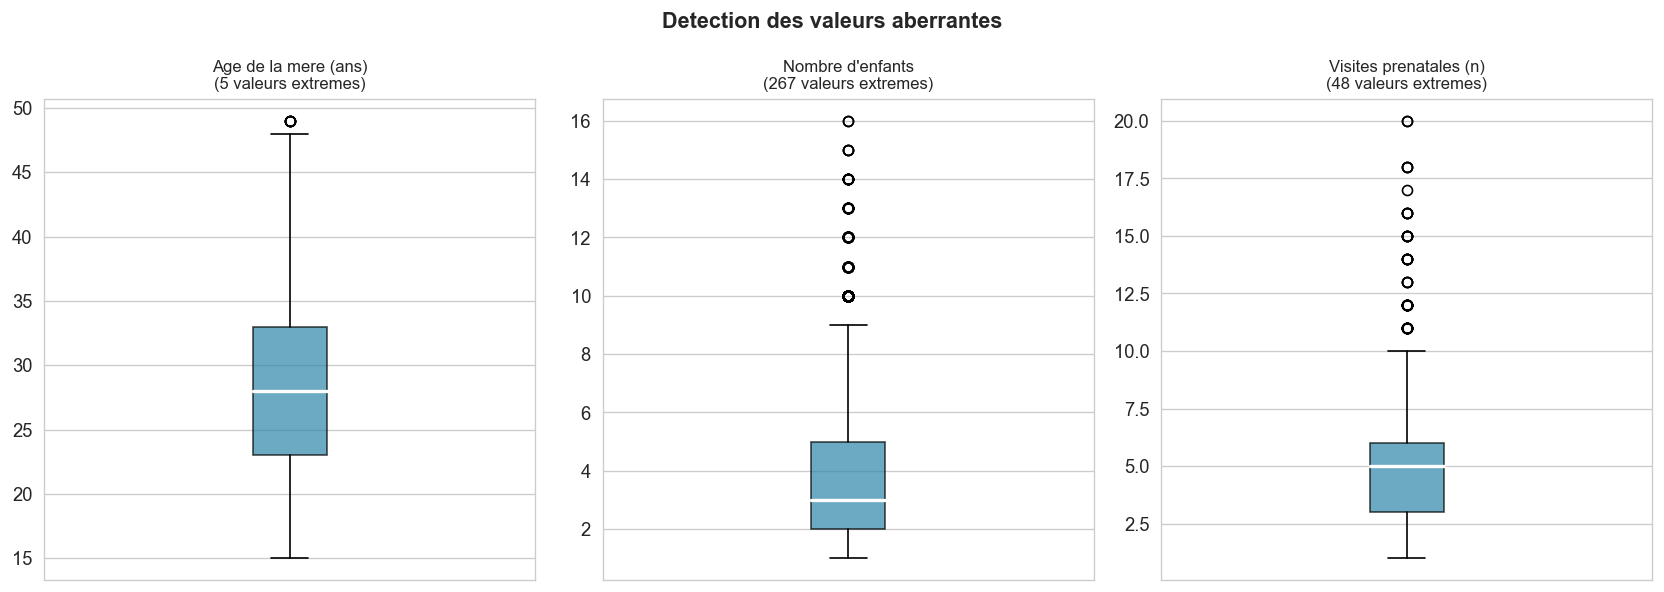

            Age de la mere (ans)  Nombre d'enfants  Visites prenatales (n)
n                       9717.000          9717.000                5563.000
Moyenne                   28.220             3.850                   4.860
Ecart-type                 6.680             2.390                   1.990
Min                       15.000             1.000                   1.000
Q1                        23.000             2.000                   3.000
Mediane                   28.000             3.000                   5.000
Q3                        33.000             5.000                   6.000
Max                       49.000            16.000                  20.000


In [15]:
vars_num    = ['age_mere', 'nombre_enfants', 'visites_prenatales']
labels_num  = ['Age de la mere (ans)', "Nombre d'enfants", 'Visites prenatales (n)']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, var, label in zip(axes, vars_num, labels_num):
    data_plot = df[var].dropna()
    ax.boxplot(data_plot, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#2E86AB', alpha=0.7),
               medianprops=dict(color='white', linewidth=2))
    q1, q3 = data_plot.quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = data_plot[(data_plot < q1 - 1.5*iqr) | (data_plot > q3 + 1.5*iqr)]
    ax.set_title(f'{label}\n({len(outliers)} valeurs extremes)', fontsize=10)
    ax.set_xticks([])

plt.suptitle('Detection des valeurs aberrantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()

stats_num = df[vars_num].describe().round(2)
stats_num.columns = labels_num
stats_num.index = ['n', 'Moyenne', 'Ecart-type', 'Min', 'Q1', 'Mediane', 'Q3', 'Max']
print(stats_num)

### 3.5 Dataset analytique final

In [16]:
colonnes_finales = [
    'cesarienne', 'age_mere', 'age_groupe',
    'milieu_residence', 'region',
    'niveau_instruction', 'indice_richesse',
    'parite', 'nombre_enfants',
    'statut_union', 'situation_matrimoniale',
    'grossesse_desiree', 'sexe_enfant',
    'visites_prenatales', 'cva_groupe', 'cva_suffisant',
    'lieu_accouchement', 'v005'
]
df_analyse = df[colonnes_finales].copy()

print(f'Dataset analytique final :')
print(f'  Observations          : {df_analyse.shape[0]:,}')
print(f'  Variables             : {df_analyse.shape[1]}')
print(f'  Cesarienne            : {int(df_analyse["cesarienne"].sum()):,} ({df_analyse["cesarienne"].mean()*100:.1f}%)')
print(f'  Accouchement vaginal  : {int((df_analyse["cesarienne"]==0).sum()):,} ({(df_analyse["cesarienne"]==0).mean()*100:.1f}%)')

df_analyse.to_csv('data_cesarienne_final.csv', index=False)
print('\nDataset exporte : data_cesarienne_final.csv')

Dataset analytique final :
  Observations          : 9,717
  Variables             : 18
  Cesarienne            : 352 (3.6%)
  Accouchement vaginal  : 9,365 (96.4%)

Dataset exporte : data_cesarienne_final.csv


---
## 4. Analyse descriptive univariee

### 4.1 Variable dependante

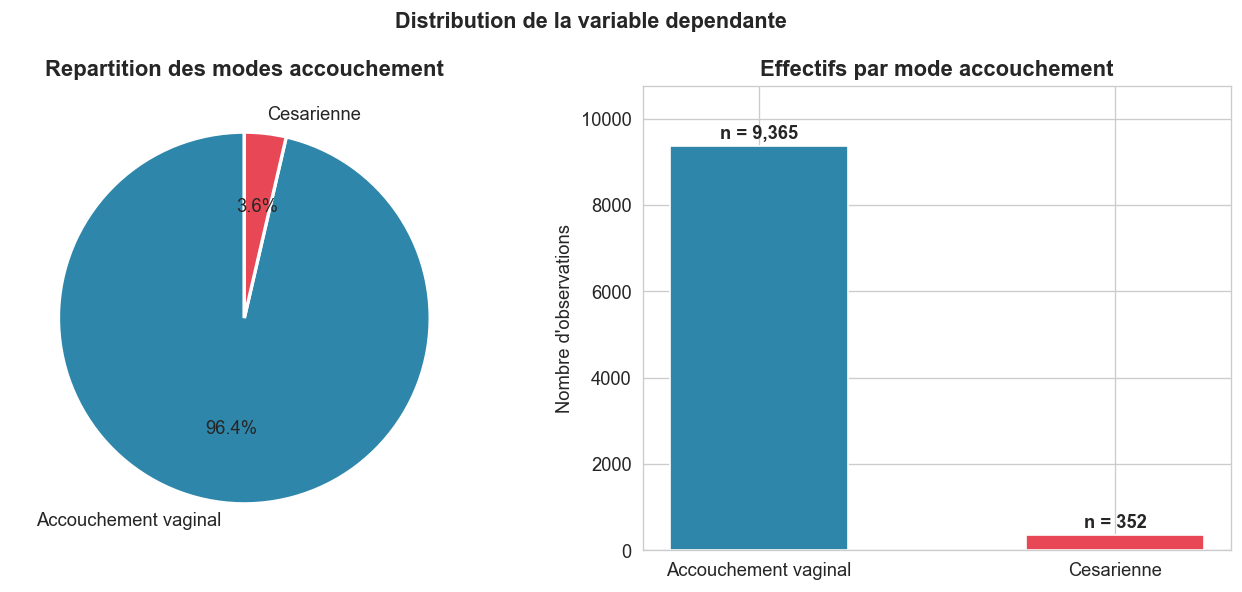

Taux cesarienne  : 3.6% (n=352)
Taux voie basse  : 96.4% (n=9,365)


In [17]:
counts = df_analyse['cesarienne'].value_counts()
labels_dep = ['Accouchement vaginal', 'Cesarienne']
colors_dep = ['#2E86AB', '#E84855']
values_dep = [counts[0], counts[1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
ax1.pie(values_dep, labels=labels_dep, colors=colors_dep,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Repartition des modes accouchement', fontweight='bold')

bars = ax2.bar(labels_dep, values_dep, color=colors_dep, width=0.5)
for bar, count in zip(bars, values_dep):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
             f'n = {count:,}', ha='center', va='bottom', fontweight='bold')
ax2.set_ylabel("Nombre d'observations")
ax2.set_title('Effectifs par mode accouchement', fontweight='bold')
ax2.set_ylim(0, max(values_dep) * 1.15)

plt.suptitle('Distribution de la variable dependante', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_variable_dependante.png', bbox_inches='tight')
plt.show()
print(f'Taux cesarienne  : {counts[1]/len(df_analyse)*100:.1f}% (n={counts[1]:,})')
print(f'Taux voie basse  : {counts[0]/len(df_analyse)*100:.1f}% (n={counts[0]:,})')

### 4.2 Variables independantes — tableaux de frequences

In [18]:
def tableau_freq(df, var, label):
    tab = df[var].value_counts(dropna=False)
    pct = (tab / len(df) * 100).round(1)
    return pd.DataFrame({'Variable': label, 'Modalite': tab.index.astype(str),
                         'n': tab.values, '%': pct.values})

vars_desc = [
    ('age_groupe',         'Groupe age'),
    ('milieu_residence',   'Milieu de residence'),
    ('niveau_instruction', "Niveau d'instruction"),
    ('indice_richesse',    'Indice de richesse'),
    ('parite',             'Parite'),
    ('statut_union',       'Statut matrimonial'),
    ('grossesse_desiree',  'Grossesse desiree'),
    ('sexe_enfant',        'Sexe de l enfant'),
    ('cva_groupe',         'Visites prenatales'),
    ('lieu_accouchement',  "Lieu d'accouchement"),
]
tableau_complet = pd.concat(
    [tableau_freq(df_analyse, var, label) for var, label in vars_desc],
    ignore_index=True
)
print('Tableau descriptif des variables independantes :')
print(tableau_complet.to_string(index=False))

Tableau descriptif des variables independantes :
            Variable          Modalite    n      %
          Groupe age       20 a 34 ans 7013 72.200
          Groupe age    35 ans et plus 1859 19.100
          Groupe age   Moins de 20 ans  845  8.700
 Milieu de residence             Rural 5412 55.700
 Milieu de residence            Urbain 4305 44.300
Niveau d'instruction        Secondaire 3742 38.500
Niveau d'instruction          Primaire 3233 33.300
Niveau d'instruction            Aucune 2243 23.100
Niveau d'instruction         Superieur  499  5.100
  Indice de richesse             Moyen 2329 24.000
  Indice de richesse            Pauvre 2282 23.500
  Indice de richesse             Riche 1890 19.500
  Indice de richesse       Tres pauvre 1807 18.600
  Indice de richesse        Tres riche 1409 14.500
              Parite         Multipare 8233 84.700
              Parite         Primipare 1484 15.300
  Statut matrimonial          En union 7870 81.000
  Statut matrimonial      Pas en 

In [19]:
print('Statistiques des variables continues :')
stats_cont = df_analyse[['age_mere', 'nombre_enfants', 'visites_prenatales']].describe().round(2)
stats_cont.index = ['n', 'Moyenne', 'Ecart-type', 'Min', 'Q1', 'Mediane', 'Q3', 'Max']
stats_cont.columns = ['Age mere (ans)', "Nb enfants", 'Visites prenatales']
print(stats_cont)

Statistiques des variables continues :
            Age mere (ans)  Nb enfants  Visites prenatales
n                 9717.000    9717.000            5563.000
Moyenne             28.220       3.850               4.860
Ecart-type           6.680       2.390               1.990
Min                 15.000       1.000               1.000
Q1                  23.000       2.000               3.000
Mediane             28.000       3.000               5.000
Q3                  33.000       5.000               6.000
Max                 49.000      16.000              20.000


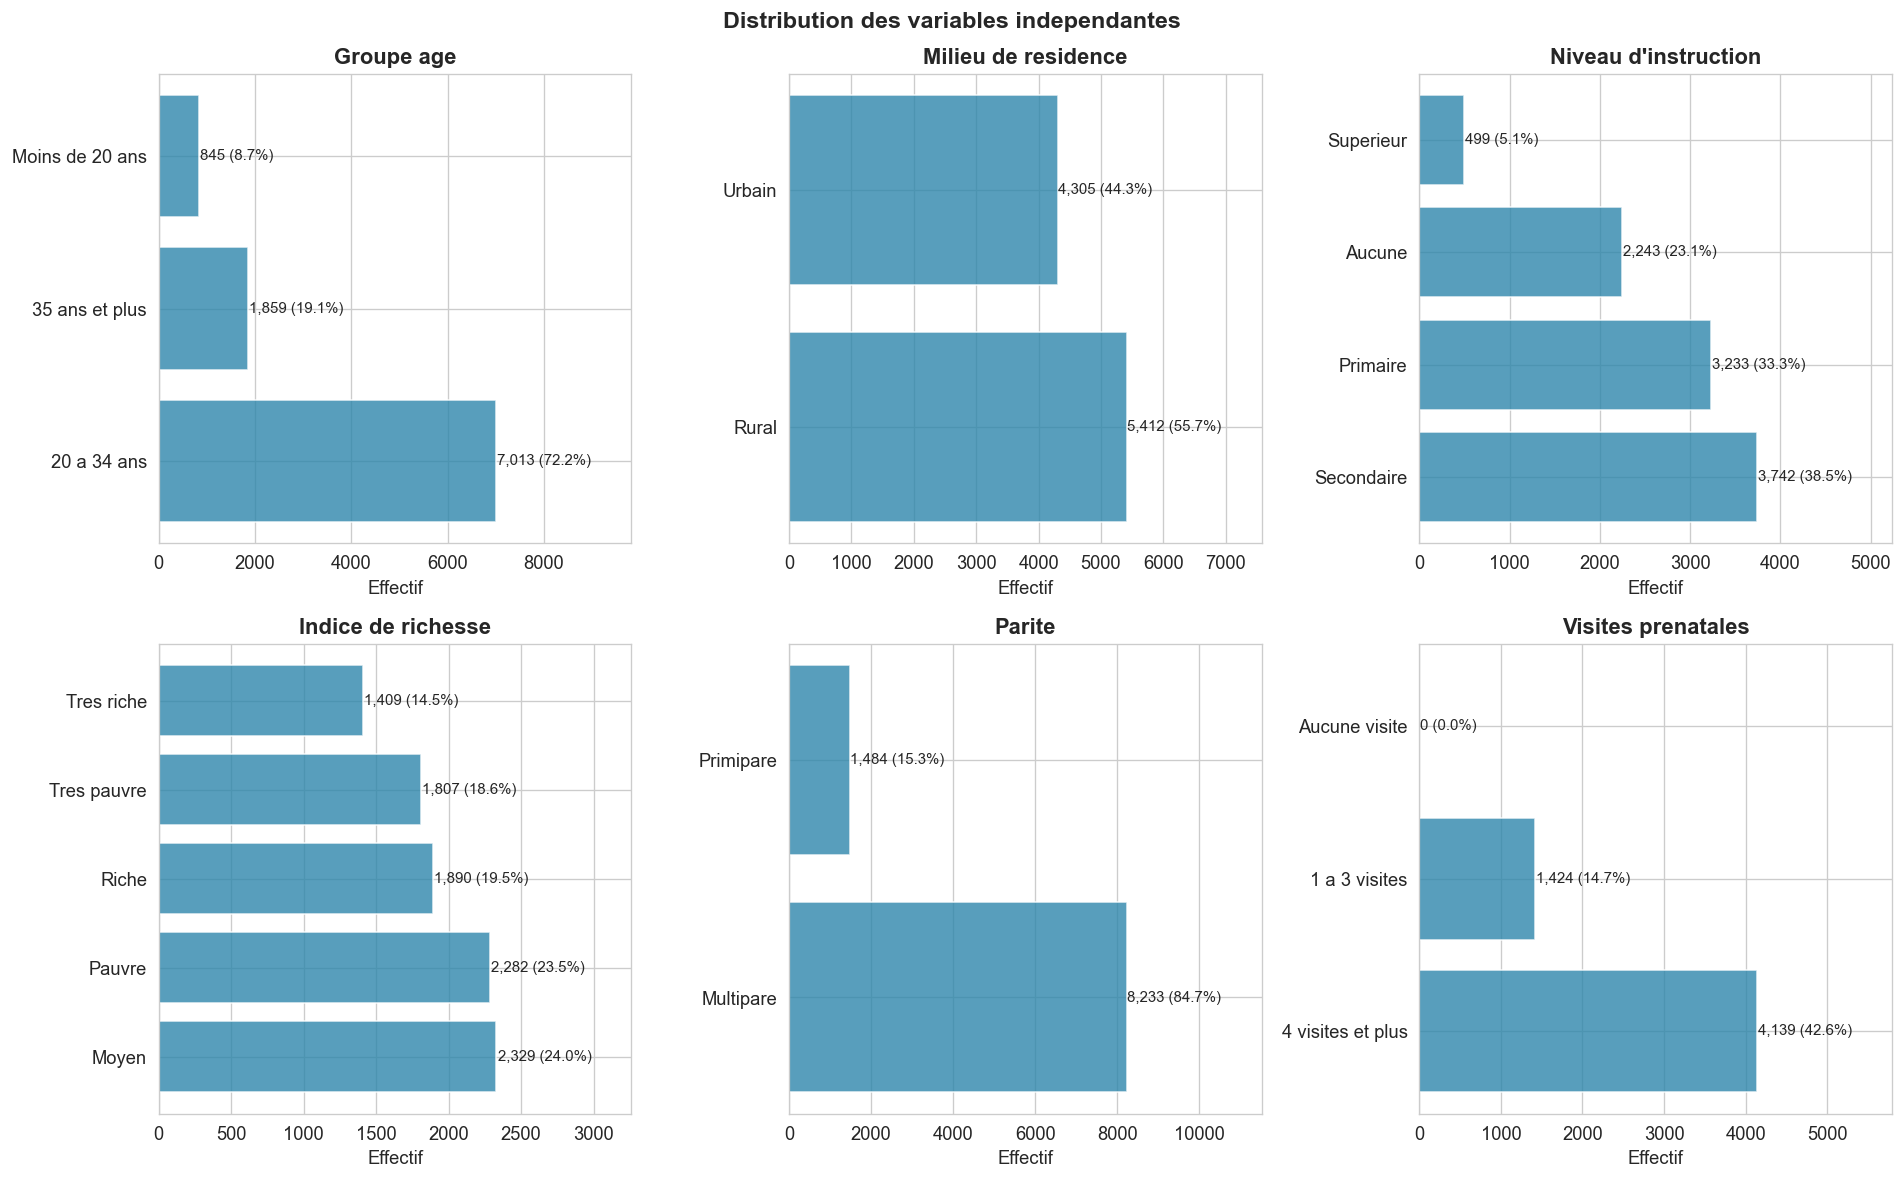

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
vars_plot = [
    ('age_groupe',         'Groupe age'),
    ('milieu_residence',   'Milieu de residence'),
    ('niveau_instruction', "Niveau d'instruction"),
    ('indice_richesse',    'Indice de richesse'),
    ('parite',             'Parite'),
    ('cva_groupe',         'Visites prenatales'),
]
for ax, (var, label) in zip(axes, vars_plot):
    data_var = df_analyse[var].value_counts()
    bars = ax.barh(data_var.index.astype(str), data_var.values, color='#2E86AB', alpha=0.8)
    for bar, val in zip(bars, data_var.values):
        ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({val/len(df_analyse)*100:.1f}%)', va='center', fontsize=9)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Effectif')
    ax.set_xlim(0, data_var.max() * 1.4)
plt.suptitle('Distribution des variables independantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_distribution_variables.png', bbox_inches='tight')
plt.show()

---
## 5. Analyse bivariee

In [21]:
def analyse_bivariee_cat(df, var, label):
    data = df[[var, 'cesarienne']].dropna()
    tab = pd.crosstab(data[var], data['cesarienne'])
    if tab.shape[1] < 2 or 1 not in tab.columns:
        return None
    tab.columns = ['Vaginal (n)', 'Cesarienne (n)']
    tab['Total'] = tab.sum(axis=1)
    tab['% Cesarienne'] = (tab['Cesarienne (n)'] / tab['Total'] * 100).round(1)
    chi2, p, dof, _ = chi2_contingency(pd.crosstab(data[var], data['cesarienne']))
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'\n-- {label} --')
    print(tab.to_string())
    print(f'Chi2 = {chi2:.2f} | ddl = {dof} | p = {p:.4f} {sig}')
    return {'variable': label, 'chi2': round(chi2, 2), 'p_valeur': round(p, 4)}

vars_cat_bivar = [
    ('age_groupe',         'Groupe age'),
    ('milieu_residence',   'Milieu de residence'),
    ('niveau_instruction', "Niveau d'instruction"),
    ('indice_richesse',    'Indice de richesse'),
    ('parite',             'Parite'),
    ('statut_union',       'Statut matrimonial'),
    ('grossesse_desiree',  'Grossesse desiree'),
    ('sexe_enfant',        'Sexe de l enfant'),
    ('cva_suffisant',      'Visites prenatales (suffisantes)'),
    ('lieu_accouchement',  "Lieu d'accouchement"),
]
resultats_bivar = []
for var, label in vars_cat_bivar:
    r = analyse_bivariee_cat(df_analyse, var, label)
    if r:
        resultats_bivar.append(r)


-- Groupe age --
                 Vaginal (n)  Cesarienne (n)  Total  % Cesarienne
age_groupe                                                       
Moins de 20 ans          826              19    845         2.200
20 a 34 ans             6760             253   7013         3.600
35 ans et plus          1779              80   1859         4.300
Chi2 = 7.04 | ddl = 2 | p = 0.0296 *

-- Milieu de residence --
                  Vaginal (n)  Cesarienne (n)  Total  % Cesarienne
milieu_residence                                                  
Rural                    5312             100   5412         1.800
Urbain                   4053             252   4305         5.900
Chi2 = 109.06 | ddl = 1 | p = 0.0000 ***

-- Niveau d'instruction --
                    Vaginal (n)  Cesarienne (n)  Total  % Cesarienne
niveau_instruction                                                  
Aucune                     2227              16   2243         0.700
Primaire                   3156             

In [22]:
print('-- Tests de Student (variables continues) --\n')
for var, label in [
    ('age_mere',           'Age de la mere'),
    ('nombre_enfants',     "Nombre d'enfants"),
    ('visites_prenatales', 'Visites prenatales')
]:
    g0 = df_analyse[df_analyse['cesarienne'] == 0][var].dropna()
    g1 = df_analyse[df_analyse['cesarienne'] == 1][var].dropna()
    t, p = stats.ttest_ind(g0, g1)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f'{label} :')
    print(f'  Voie basse  : moy = {g0.mean():.2f} +/- {g0.std():.2f}')
    print(f'  Cesarienne  : moy = {g1.mean():.2f} +/- {g1.std():.2f}')
    print(f'  t = {t:.3f} | p = {p:.4f} {sig}\n')

-- Tests de Student (variables continues) --

Age de la mere :
  Voie basse  : moy = 28.18 +/- 6.68
  Cesarienne  : moy = 29.51 +/- 6.55
  t = -3.673 | p = 0.0002 ***

Nombre d'enfants :
  Voie basse  : moy = 3.89 +/- 2.40
  Cesarienne  : moy = 2.79 +/- 1.78
  t = 8.486 | p = 0.0000 ***

Visites prenatales :
  Voie basse  : moy = 4.81 +/- 1.96
  Cesarienne  : moy = 5.99 +/- 2.32
  t = -9.590 | p = 0.0000 ***



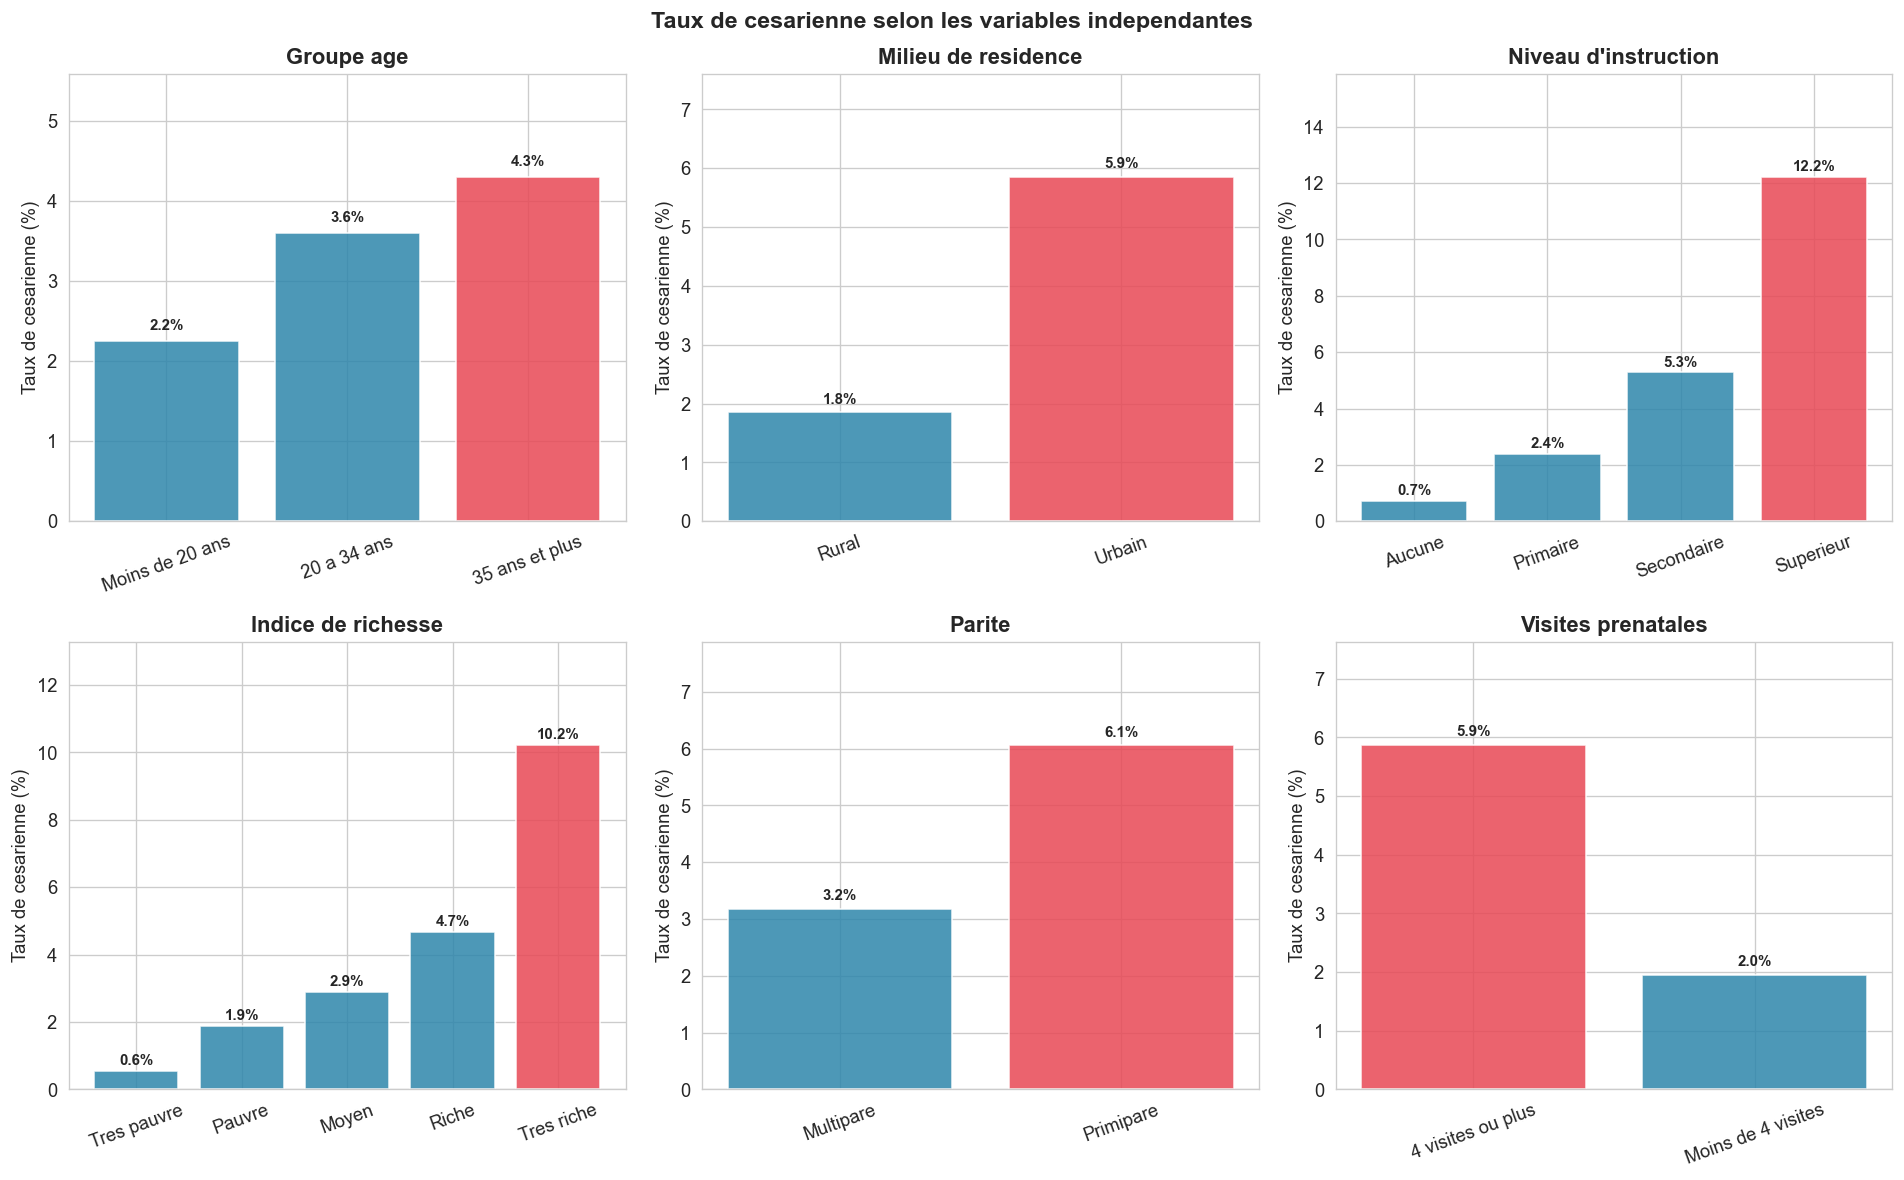

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
vars_bivar_plot = [
    ('age_groupe',         'Groupe age'),
    ('milieu_residence',   'Milieu de residence'),
    ('niveau_instruction', "Niveau d'instruction"),
    ('indice_richesse',    'Indice de richesse'),
    ('parite',             'Parite'),
    ('cva_suffisant',      'Visites prenatales'),
]
for ax, (var, label) in zip(axes, vars_bivar_plot):
    taux = df_analyse.dropna(subset=[var]).groupby(var, observed=True)['cesarienne'].mean() * 100
    colors_b = ['#E84855' if v == taux.max() else '#2E86AB' for v in taux.values]
    bars = ax.bar(taux.index.astype(str), taux.values, color=colors_b, alpha=0.85)
    for bar, val in zip(bars, taux.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Taux de cesarienne (%)')
    ax.set_ylim(0, taux.max() * 1.3)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Taux de cesarienne selon les variables independantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_analyse_bivariee.png', bbox_inches='tight')
plt.show()

In [24]:
df_bivar = pd.DataFrame(resultats_bivar)
df_bivar['Signification']   = df_bivar['p_valeur'].apply(lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')
df_bivar['Retenue (p<0.20)'] = df_bivar['p_valeur'].apply(lambda p: 'Oui' if p < 0.20 else 'Non')
print('Resume tests Chi2 :')
print(df_bivar.to_string(index=False))

Resume tests Chi2 :
                        variable    chi2  p_valeur Signification Retenue (p<0.20)
                      Groupe age   7.040     0.030             *              Oui
             Milieu de residence 109.060     0.000           ***              Oui
            Niveau d'instruction 204.230     0.000           ***              Oui
              Indice de richesse 253.660     0.000           ***              Oui
                          Parite  29.100     0.000           ***              Oui
              Statut matrimonial  13.540     0.000           ***              Oui
               Grossesse desiree   1.390     0.498            ns              Non
                Sexe de l enfant   7.400     0.006            **              Oui
Visites prenatales (suffisantes) 103.290     0.000           ***              Oui
             Lieu d'accouchement 209.540     0.000           ***              Oui


---
## 6. Regression logistique univariee

In [25]:
vars_regression = [
    'age_groupe', 'milieu_residence', 'niveau_instruction',
    'indice_richesse', 'parite', 'statut_union',
    'grossesse_desiree', 'sexe_enfant', 'cva_suffisant', 'lieu_accouchement'
]

def regression_univariee(df, var_dep, var_indep):
    data = df[[var_dep, var_indep]].dropna()
    dummies = pd.get_dummies(data[var_indep], drop_first=True, dtype=float)
    X = sm.add_constant(dummies)
    y = data[var_dep].astype(float)
    try:
        model = sm.Logit(y, X).fit(disp=0)
        results = []
        for col in dummies.columns:
            OR = np.exp(model.params[col])
            CI = model.conf_int()
            results.append({
                'Variable':    var_indep,
                'Modalite':    col,
                'OR brut':     round(OR, 2),
                'IC 95% bas':  round(np.exp(CI.loc[col, 0]), 2),
                'IC 95% haut': round(np.exp(CI.loc[col, 1]), 2),
                'p-valeur':    round(model.pvalues[col], 4)
            })
        return results
    except Exception as e:
        print(f'Erreur {var_indep} : {e}')
        return []

tous_resultats_uni = []
for var in vars_regression:
    tous_resultats_uni.extend(regression_univariee(df_analyse, 'cesarienne', var))

df_uni = pd.DataFrame(tous_resultats_uni)
df_uni['Signification'] = df_uni['p-valeur'].apply(lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')
print('Resultats regression logistique UNIVARIEE :')
print(df_uni.to_string(index=False))

Resultats regression logistique UNIVARIEE :
          Variable           Modalite       OR brut  IC 95% bas  IC 95% haut  p-valeur Signification
        age_groupe        20 a 34 ans         1.630       1.020        2.610     0.043             *
        age_groupe     35 ans et plus         1.950       1.180        3.250     0.009            **
  milieu_residence             Urbain         3.300       2.610        4.180     0.000           ***
niveau_instruction           Primaire         3.400       1.980        5.830     0.000           ***
niveau_instruction         Secondaire         7.780       4.660       12.980     0.000           ***
niveau_instruction          Superieur        19.380      11.070       33.930     0.000           ***
   indice_richesse             Pauvre         3.450       1.730        6.890     0.000           ***
   indice_richesse              Moyen         5.320       2.730       10.370     0.000           ***
   indice_richesse              Riche         8

---
## 7. Regression logistique multivariee

In [26]:
vars_sign = df_uni[df_uni['p-valeur'] < 0.10]['Variable'].unique().tolist()
print(f'Variables retenues (p<0.10) : {len(vars_sign)}')
for v in vars_sign:
    print(f'  - {v}')

Variables retenues (p<0.10) : 8
  - age_groupe
  - milieu_residence
  - niveau_instruction
  - indice_richesse
  - parite
  - statut_union
  - sexe_enfant
  - cva_suffisant


In [27]:
# Retirer lieu_accouchement de vars_sign
vars_sign = [v for v in vars_sign if v != 'lieu_accouchement']

# Relancer le modèle
df_multi   = df_analyse[['cesarienne'] + vars_sign].dropna()
X_multi    = pd.get_dummies(df_multi[vars_sign], drop_first=True, dtype=float)
X_multi    = sm.add_constant(X_multi)
y_multi    = df_multi['cesarienne'].astype(float)
modele_multi = sm.Logit(y_multi, X_multi).fit()

Optimization terminated successfully.
         Current function value: 0.139286
         Iterations 9


In [28]:
df_multi   = df_analyse[['cesarienne'] + vars_sign].dropna()
X_multi    = pd.get_dummies(df_multi[vars_sign], drop_first=True, dtype=float)
X_multi    = sm.add_constant(X_multi)
y_multi    = df_multi['cesarienne'].astype(float)
modele_multi = sm.Logit(y_multi, X_multi).fit()
print(modele_multi.summary())

Optimization terminated successfully.
         Current function value: 0.139286
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             cesarienne   No. Observations:                 9717
Model:                          Logit   Df Residuals:                     9702
Method:                           MLE   Df Model:                           14
Date:              ven., 24 avr. 2026   Pseudo R-squ.:                  0.1057
Time:                        14:57:51   Log-Likelihood:                -1353.4
converged:                       True   LL-Null:                       -1513.5
Covariance Type:            nonrobust   LLR p-value:                 7.574e-60
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -5.9591      0.454    -13.13

In [29]:
df_multi_results = pd.DataFrame({
    'Variable':    modele_multi.params.index,
    'OR ajuste':   np.exp(modele_multi.params).round(2),
    'IC 95% bas':  np.exp(modele_multi.conf_int()[0]).round(2),
    'IC 95% haut': np.exp(modele_multi.conf_int()[1]).round(2),
    'p-valeur':    modele_multi.pvalues.round(4)
}).reset_index(drop=True)
df_multi_results['Signification'] = df_multi_results['p-valeur'].apply(lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')
df_multi_final = df_multi_results[df_multi_results['Variable'] != 'const'].copy()
print('Odds Ratios ajustes — Modele multivaried :')
print(df_multi_final.to_string(index=False))

Odds Ratios ajustes — Modele multivaried :
                        Variable  OR ajuste  IC 95% bas  IC 95% haut  p-valeur Signification
          age_groupe_20 a 34 ans      1.610       0.970        2.670     0.063            ns
       age_groupe_35 ans et plus      2.240       1.280        3.930     0.005            **
         milieu_residence_Urbain      1.230       0.900        1.680     0.204            ns
     niveau_instruction_Primaire      2.190       1.250        3.840     0.006            **
   niveau_instruction_Secondaire      3.180       1.830        5.540     0.000           ***
    niveau_instruction_Superieur      4.540       2.420        8.510     0.000           ***
          indice_richesse_Pauvre      2.220       1.090        4.510     0.028             *
           indice_richesse_Moyen      2.630       1.290        5.350     0.008            **
           indice_richesse_Riche      3.280       1.570        6.890     0.002            **
      indice_richesse_Tres 

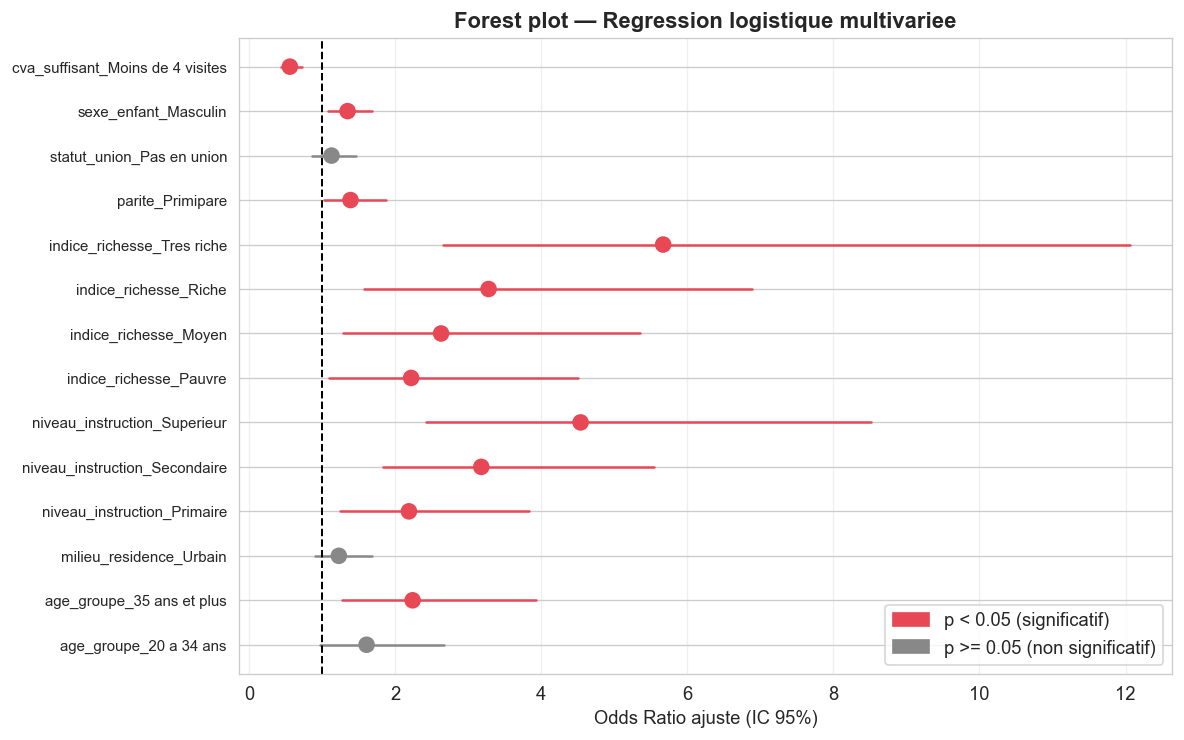

In [30]:
df_fp = df_multi_final.reset_index(drop=True)
y_pos = range(len(df_fp))
colors_fp = ['#E84855' if p < 0.05 else '#888888' for p in df_fp['p-valeur']]

fig, ax = plt.subplots(figsize=(10, max(6, len(df_fp) * 0.45)))
ax.scatter(df_fp['OR ajuste'], list(y_pos), color=colors_fp, s=80, zorder=3)
for i, row in df_fp.iterrows():
    ax.plot([row['IC 95% bas'], row['IC 95% haut']], [i, i], color=colors_fp[i], linewidth=1.5)
ax.axvline(x=1, color='black', linestyle='--', linewidth=1.2)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(df_fp['Variable'].astype(str), fontsize=9)
ax.set_xlabel('Odds Ratio ajuste (IC 95%)')
ax.set_title('Forest plot — Regression logistique multivariee', fontweight='bold')
legend_elements = [
    Patch(color='#E84855', label='p < 0.05 (significatif)'),
    Patch(color='#888888', label='p >= 0.05 (non significatif)')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_forest_plot.png', bbox_inches='tight')
plt.show()

---
## 8. Validation du modele

### 8.1 Courbe ROC et AUC

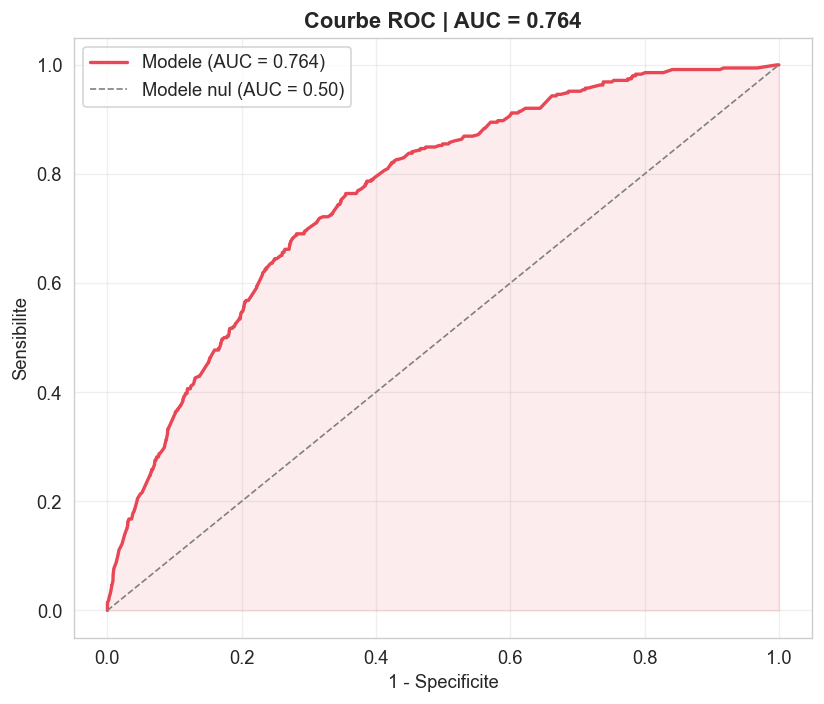

AUC = 0.764 -> Acceptable (0.70-0.80)


In [31]:
y_pred_prob = modele_multi.predict(X_multi)
fpr, tpr, _ = roc_curve(y_multi, y_pred_prob)
auc_score   = roc_auc_score(y_multi, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#E84855', linewidth=2, label=f'Modele (AUC = {auc_score:.3f})')
ax.plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Modele nul (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='#E84855')
ax.set_xlabel('1 - Specificite')
ax.set_ylabel('Sensibilite')
ax.set_title(f'Courbe ROC | AUC = {auc_score:.3f}', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_courbe_roc.png', bbox_inches='tight')
plt.show()
interp = ('Excellent (>0.90)' if auc_score>0.90 else 'Bon (0.80-0.90)' if auc_score>0.80 else 'Acceptable (0.70-0.80)' if auc_score>0.70 else 'Faible (<0.70)')
print(f'AUC = {auc_score:.3f} -> {interp}')

### 8.2 Test de Hosmer-Lemeshow

In [32]:
def hosmer_lemeshow(y_obs, y_pred, g=10):
    data = pd.DataFrame({'obs': y_obs.values, 'pred': y_pred.values})
    data['decile'] = pd.qcut(data['pred'], q=g, duplicates='drop')
    grp = data.groupby('decile', observed=True).agg(
        obs_cas=('obs','sum'), n=('obs','count'), pred_moy=('pred','mean')
    )
    grp['pred_cas'] = grp['pred_moy'] * grp['n']
    grp['obs_non']  = grp['n'] - grp['obs_cas']
    grp['pred_non'] = grp['n'] - grp['pred_cas']
    hl  = ((grp['obs_cas'] - grp['pred_cas'])**2 / grp['pred_cas'] +
           (grp['obs_non'] - grp['pred_non'])**2 / grp['pred_non']).sum()
    dof = len(grp) - 2
    p   = 1 - stats.chi2.cdf(hl, dof)
    return hl, dof, p

hl_stat, dof_hl, p_hl = hosmer_lemeshow(y_multi, y_pred_prob)
print(f'Test de Hosmer-Lemeshow :')
print(f'  chi2 = {hl_stat:.3f} | ddl = {dof_hl} | p = {p_hl:.4f}')
print('  -> Bonne calibration.' if p_hl > 0.05 else '  -> Calibration a ameliorer.')

Test de Hosmer-Lemeshow :
  chi2 = 8.278 | ddl = 8 | p = 0.4068
  -> Bonne calibration.


### 8.3 Multicolinearite (VIF)

In [33]:
X_vif = X_multi.drop(columns=['const'])
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data['VIF'] = vif_data['VIF'].round(2)
vif_data['Interpretation'] = vif_data['VIF'].apply(
    lambda v: 'Probleme severe (>10)' if v>10 else 'Modere (5-10)' if v>5 else 'Acceptable (<5)'
)
print('Variance Inflation Factor (VIF) :')
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))
max_vif = vif_data['VIF'].max()
print('\nConclusion :', 'Aucun probleme (VIF max < 5).' if max_vif < 5 else 'Multicolinearite moderee.' if max_vif < 10 else 'Multicolinearite severe.')

Variance Inflation Factor (VIF) :
                        Variable   VIF  Interpretation
          age_groupe_20 a 34 ans 5.040   Modere (5-10)
   niveau_instruction_Secondaire 3.660 Acceptable (<5)
           indice_richesse_Riche 3.410 Acceptable (<5)
      indice_richesse_Tres riche 3.410 Acceptable (<5)
         milieu_residence_Urbain 3.350 Acceptable (<5)
           indice_richesse_Moyen 2.890 Acceptable (<5)
     niveau_instruction_Primaire 2.600 Acceptable (<5)
cva_suffisant_Moins de 4 visites 2.280 Acceptable (<5)
          indice_richesse_Pauvre 2.270 Acceptable (<5)
       age_groupe_35 ans et plus 2.000 Acceptable (<5)
            sexe_enfant_Masculin 1.950 Acceptable (<5)
    niveau_instruction_Superieur 1.650 Acceptable (<5)
       statut_union_Pas en union 1.390 Acceptable (<5)
                parite_Primipare 1.380 Acceptable (<5)

Conclusion : Multicolinearite moderee.


---
## Tableau recapitulatif final

In [34]:
print('='*78)
print('  FACTEURS ASSOCIES A LA CESARIENNE — EDS CAMEROUN 2018')
print('  Regression logistique multivariee')
print('='*78)
print(f"  {'Variable':<42} {'OR':>6} {'IC 95%':>18} {'p':>8} {'Sig':>5}")
print('-'*78)
for _, row in df_multi_final.iterrows():
    ic = f"[{row['IC 95% bas']:.2f} ; {row['IC 95% haut']:.2f}]"
    print(f"  {str(row['Variable']):<42} {row['OR ajuste']:>6.2f} {ic:>18} {row['p-valeur']:>8.4f} {row['Signification']:>5}")
print('-'*78)
print(f'  n = {len(y_multi):,} | Cesarienne : {int(y_multi.sum())} ({y_multi.mean()*100:.1f}%)')
print(f'  AUC = {auc_score:.3f} | Hosmer-Lemeshow : chi2={hl_stat:.2f}, p={p_hl:.4f}')
print('='*78)
print('  Codes : *** p<0.001  ** p<0.01  * p<0.05  ns = non significatif')

  FACTEURS ASSOCIES A LA CESARIENNE — EDS CAMEROUN 2018
  Regression logistique multivariee
  Variable                                       OR             IC 95%        p   Sig
------------------------------------------------------------------------------
  age_groupe_20 a 34 ans                       1.61      [0.97 ; 2.67]   0.0634    ns
  age_groupe_35 ans et plus                    2.24      [1.28 ; 3.93]   0.0049    **
  milieu_residence_Urbain                      1.23      [0.90 ; 1.68]   0.2041    ns
  niveau_instruction_Primaire                  2.19      [1.25 ; 3.84]   0.0059    **
  niveau_instruction_Secondaire                3.18      [1.83 ; 5.54]   0.0000   ***
  niveau_instruction_Superieur                 4.54      [2.42 ; 8.51]   0.0000   ***
  indice_richesse_Pauvre                       2.22      [1.09 ; 4.51]   0.0280     *
  indice_richesse_Moyen                        2.63      [1.29 ; 5.35]   0.0076    **
  indice_richesse_Riche                        3.28    

In [35]:
# Étape 1 : Retirer lieu_accouchement et relancer
vars_sign = [v for v in vars_sign if v != 'lieu_accouchement']

df_multi     = df_analyse[['cesarienne'] + vars_sign].dropna()
X_multi      = pd.get_dummies(df_multi[vars_sign], drop_first=True, dtype=float)
X_multi      = sm.add_constant(X_multi)
y_multi      = df_multi['cesarienne'].astype(float)
modele_multi = sm.Logit(y_multi, X_multi).fit()

# Étape 2 : Tableau propre des résultats
df_final = pd.DataFrame({
    'Variable':    modele_multi.params.index,
    'OR ajuste':   np.exp(modele_multi.params).round(2),
    'IC 95% bas':  np.exp(modele_multi.conf_int()[0]).round(2),
    'IC 95% haut': np.exp(modele_multi.conf_int()[1]).round(2),
    'p-valeur':    modele_multi.pvalues.round(4)
}).reset_index(drop=True)

df_final['Sig'] = df_final['p-valeur'].apply(
    lambda p: '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
)

print(df_final[df_final['Variable'] != 'const'].to_string(index=False))

# Étape 3 : AUC
from sklearn.metrics import roc_auc_score
y_pred = modele_multi.predict(X_multi)
print(f'\nAUC = {roc_auc_score(y_multi, y_pred):.3f}')

Optimization terminated successfully.
         Current function value: 0.139286
         Iterations 9
                        Variable  OR ajuste  IC 95% bas  IC 95% haut  p-valeur Sig
          age_groupe_20 a 34 ans      1.610       0.970        2.670     0.063  ns
       age_groupe_35 ans et plus      2.240       1.280        3.930     0.005  **
         milieu_residence_Urbain      1.230       0.900        1.680     0.204  ns
     niveau_instruction_Primaire      2.190       1.250        3.840     0.006  **
   niveau_instruction_Secondaire      3.180       1.830        5.540     0.000 ***
    niveau_instruction_Superieur      4.540       2.420        8.510     0.000 ***
          indice_richesse_Pauvre      2.220       1.090        4.510     0.028   *
           indice_richesse_Moyen      2.630       1.290        5.350     0.008  **
           indice_richesse_Riche      3.280       1.570        6.890     0.002  **
      indice_richesse_Tres riche      5.670       2.660       12.060